# ⚡ EnerVision AI — Bi-LSTM Model

**Standalone Notebook**

This notebook trains and evaluates a single deep learning model, **Bi-LSTM**, as part of the **EnerVision AI** household energy-forecasting project.
It is designed to run independently in a fresh Google Colab session, with GPU recommended for faster training.

| | |
|---|---|
| **Project** | EnerVision AI |
| **Model** | Bi-LSTM |
| **Task** | Household energy-consumption forecasting |
| **Dataset** | `HomeC_Cleaned.csv` |
| **Environment** | Google Colab (GPU recommended) |

---


## 📦 Step 1: Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## 📂 Step 2: Load Data


In [ ]:
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/EnerVision_AI/Data/HomecCleaned.csv', low_memory=False)

print(f"✅ Data loaded successfully! Data size: {df.shape}")

display(df.head())

Mounted at /content/drive
✅ Data loaded successfully! Data size: (502470, 49)


,time,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],...,hour_sin,hour_cos,month_sin,month_cos,Net_Energy_lag1,Net_Energy_lag60,Net_Energy_lag1440,Demand_lag1,Demand_lag60,Demand_lag1440
0,2016-01-02 05:00:00,1.819400,0.003400,1.819400,0.114633,0.487533,0.681517,0.051050,0.136367,0.007533,...,0.965926,0.258819,0.5,0.866025,-2.904950,-0.875917,-0.929350,2.908333,0.879450,0.932833
1,2016-01-02 05:01:00,1.795433,0.003367,1.795433,0.114683,0.460867,0.683850,0.050967,0.136383,0.007417,...,0.965926,0.258819,0.5,0.866025,-1.816000,-0.685133,-0.930867,1.819400,0.688583,0.934333
2,2016-01-02 05:02:00,1.768767,0.003383,1.768767,0.114783,0.438900,0.680333,0.051017,0.136067,0.007567,...,0.965926,0.258819,0.5,0.866025,-1.792067,-0.475283,-0.928350,1.795433,0.478733,0.931817
3,2016-01-02 05:03:00,1.450383,0.003383,1.450383,0.114717,0.113017,0.683817,0.050533,0.135983,0.007567,...,0.965926,0.258819,0.5,0.866025,-1.765383,-0.470150,-1.018567,1.768767,0.473583,1.022050
4,2016-01-02 05:04:00,1.363600,0.003333,1.363600,0.114683,0.021700,0.687483,0.050333,0.135817,0.007433,...,0.965926,0.258819,0.5,0.866025,-1.447000,-0.468200,-1.135933,1.450383,0.471617,1.139400


## 🎯 Step 3: Assign X and y


In [ ]:
ignore_cols = [
    # non-numeric / identifier columns
    'time', 'icon', 'summary',

    # the target itself, in every raw/renamed form it appears under
    'use [kW]', 'Demand_kW',

    # solar-generation side: not needed to forecast demand, and keeping
    # the two tasks (demand vs. net-energy) cleanly separated
    'gen [kW]', 'Solar [kW]', 'Solar_kW',

    # belongs to the OTHER (net-energy) task; the real-time status
    # classifier still uses these from the actual data, but they must
    # not be used as model inputs here
    'Net_Energy', 'Net_Energy_Condition',
    'Net_Energy_lag1', 'Net_Energy_lag60', 'Net_Energy_lag1440',

    # superseded by the cyclical (sin/cos) time encodings below
    'hour', 'month', 'dayofweek',

    'House overall [kW]', 'Dishwasher [kW]', 'Furnace 1 [kW]', 'Furnace 2 [kW]',
    'Home office [kW]', 'Fridge [kW]', 'Wine cellar [kW]', 'Garage door [kW]',
    'Kitchen 12 [kW]', 'Kitchen 14 [kW]', 'Kitchen 38 [kW]', 'Barn [kW]', 'Well [kW]',
    'Microwave [kW]', 'Living room [kW]',
]

feature_cols = [col for col in df.columns if col not in ignore_cols]

X = df[feature_cols]
y = df['Demand_kW']  # = 'use [kW]', the household consumption target

print(f"Features ({len(feature_cols)}):", feature_cols)


Features (19): ['temperature', 'humidity', 'visibility', 'apparentTemperature', 'pressure', 'windSpeed', 'cloudCover', 'windBearing', 'precipIntensity', 'dewPoint', 'precipProbability', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'Demand_lag1', 'Demand_lag60', 'Demand_lag1440']


## ✂️ Step 4: Time-Based Train/Validation/Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False  # Ensures no temporal data mixing (Time-based split)
)

# Carve a validation slice out of the training data (used for early stopping)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    shuffle=False
)

print(f"✅ X shape: {X.shape}, y shape: {y.shape}")
print(f"✅ Train set shape: {X_tr.shape}, Validation set shape: {X_val.shape}, Test set shape: {X_test.shape}")


✅ X shape: (502470, 19), y shape: (502470,)
✅ Train set shape: (341679, 19), Validation set shape: (60297, 19), Test set shape: (100494, 19)


## ⚙️ Step 5: Scale Features and Target


In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_tr_scaled = scaler_X.fit_transform(X_tr)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_tr_scaled = scaler_y.fit_transform(y_tr.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

print("✅ Scaled variables created successfully!")


✅ Scaled variables created successfully!


## 🧩 Step 6: Create Sequences


In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

def create_sequences(X_data, y_data, seq_length=24):
    xs, ys = [], []
    X_arr = np.array(X_data)
    y_arr = np.array(y_data)
    for i in range(len(X_arr) - seq_length):
        xs.append(X_arr[i:(i + seq_length)])
        ys.append(y_arr[i + seq_length])
    return torch.tensor(np.array(xs), dtype=torch.float32), torch.tensor(np.array(ys), dtype=torch.float32)

SEQ_LEN = 24
X_tr_seq, y_tr_seq = create_sequences(X_tr_scaled, y_tr_scaled, SEQ_LEN)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, SEQ_LEN)
X_te_seq, y_te_seq = create_sequences(X_test_scaled, y_test_scaled, SEQ_LEN)

train_loader = DataLoader(TensorDataset(X_tr_seq, y_tr_seq), batch_size=64, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val_seq, y_val_seq), batch_size=256, shuffle=False)
test_loader = DataLoader(TensorDataset(X_te_seq, y_te_seq), batch_size=256, shuffle=False)

print(f"✅ Train sequences: {X_tr_seq.shape} | Validation sequences: {X_val_seq.shape} | Test sequences: {X_te_seq.shape}")


Using device: cpu
✅ Train sequences: torch.Size([341655, 24, 19]) | Validation sequences: torch.Size([60273, 24, 19]) | Test sequences: torch.Size([100470, 24, 19])


## 🏗️ Step 7: Define Bi-LSTM Model Architecture


In [ ]:
import torch.nn as nn

class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(BiLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

model_bilstm = BiLSTMModel(input_size=X_tr_scaled.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_bilstm.parameters(), lr=0.001)

print(model_bilstm)


BiLSTMModel(
  (lstm): LSTM(19, 64, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


## 🚀 Step 8: Training Loop (with Early Stopping)

Instead of a fixed number of epochs, we train up to `MAX_EPOCHS` and monitor the **validation loss** each epoch. Training stops automatically once it stops improving for `PATIENCE` epochs in a row, and the best-performing weights are restored.


In [ ]:
MAX_EPOCHS = 100
PATIENCE = 5
PRINT_EVERY = 200  # print progress every N batches within an epoch

best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None
train_losses, val_losses = [], []

print(f"🚀 Starting training | Train batches/epoch: {len(train_loader)} | Val batches: {len(val_loader)}", flush=True)

for epoch in range(MAX_EPOCHS):
    # --- Train ---
    model_bilstm.train()
    epoch_loss = 0.0
    for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model_bilstm(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        if (batch_idx + 1) % PRINT_EVERY == 0:
            running_avg = epoch_loss / (batch_idx + 1)
            print(f"  Epoch {epoch+1} | batch {batch_idx+1}/{len(train_loader)} | running train loss: {running_avg:.5f}", flush=True)

    train_loss = epoch_loss / len(train_loader)

    # --- Validate ---
    model_bilstm.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model_bilstm(batch_x)
            val_loss += criterion(outputs, batch_y).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{MAX_EPOCHS} - Train Loss: {train_loss:.5f} - Val Loss: {val_loss:.5f}", flush=True)

    # --- Early stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_state = {k: v.clone() for k, v in model_bilstm.state_dict().items()}
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"⏹️ Early stopping triggered at epoch {epoch+1} (no improvement for {PATIENCE} epochs).", flush=True)
            break

# Restore the best-performing weights before evaluating/saving
model_bilstm.load_state_dict(best_state)
print(f"✅ Best validation loss: {best_val_loss:.5f} (best model weights restored).", flush=True)


🚀 Starting training | Train batches/epoch: 5339 | Val batches: 236
  Epoch 1 | batch 200/5339 | running train loss: 0.32234
  Epoch 1 | batch 400/5339 | running train loss: 0.23912
  Epoch 1 | batch 600/5339 | running train loss: 0.21023
  Epoch 1 | batch 800/5339 | running train loss: 0.19076
  Epoch 1 | batch 1000/5339 | running train loss: 0.18165
  Epoch 1 | batch 1200/5339 | running train loss: 0.18096
  Epoch 1 | batch 1400/5339 | running train loss: 0.17723
  Epoch 1 | batch 1600/5339 | running train loss: 0.16590
  Epoch 1 | batch 1800/5339 | running train loss: 0.15952
  Epoch 1 | batch 2000/5339 | running train loss: 0.15296
  Epoch 1 | batch 2200/5339 | running train loss: 0.15102
  Epoch 1 | batch 2400/5339 | running train loss: 0.14732
  Epoch 1 | batch 2600/5339 | running train loss: 0.14349
  Epoch 1 | batch 2800/5339 | running train loss: 0.14348
  Epoch 1 | batch 3000/5339 | running train loss: 0.14967
  Epoch 1 | batch 3200/5339 | running train loss: 0.14540
  Epoch 1

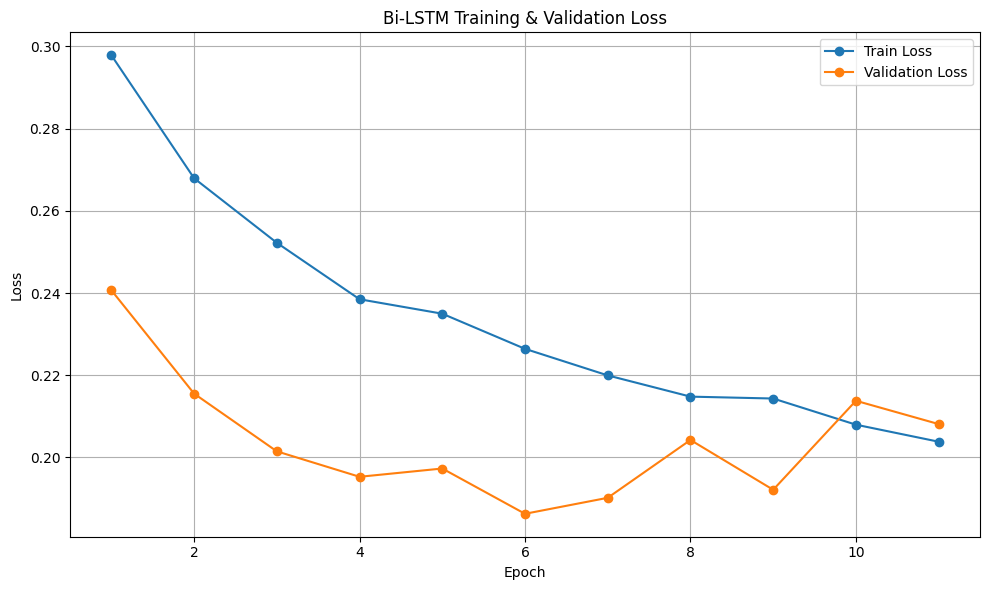

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label='Validation Loss')
plt.title('Bi-LSTM Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 📊 Step 9: Evaluate on Test Set


In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

model_bilstm.eval()
preds_scaled_list = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        batch_preds = model_bilstm(batch_x)
        preds_scaled_list.append(batch_preds.cpu().numpy())

preds_scaled = np.vstack(preds_scaled_list)

preds_bilstm = scaler_y.inverse_transform(preds_scaled)
y_test_actual = scaler_y.inverse_transform(y_te_seq.numpy())

mae_bilstm = mean_absolute_error(y_test_actual, preds_bilstm)
rmse_bilstm = root_mean_squared_error(y_test_actual, preds_bilstm)
r2_bilstm = r2_score(y_test_actual, preds_bilstm)

print("\n" + "=" * 30)
print("📊 Bi-LSTM Model Performance Evaluation:")
print(f"• RMSE (Root Mean Squared Error): {rmse_bilstm:.4f}")
print(f"• MAE (Mean Absolute Error): {mae_bilstm:.4f}")
print(f"• R2 Score (Coefficient of Determination): {r2_bilstm:.4f}")
print("=" * 30 + "\n")



📊 Bi-LSTM Model Performance Evaluation:
• RMSE (Root Mean Squared Error): 0.4078
• MAE (Mean Absolute Error): 0.2137
• R2 Score (Coefficient of Determination): 0.6152



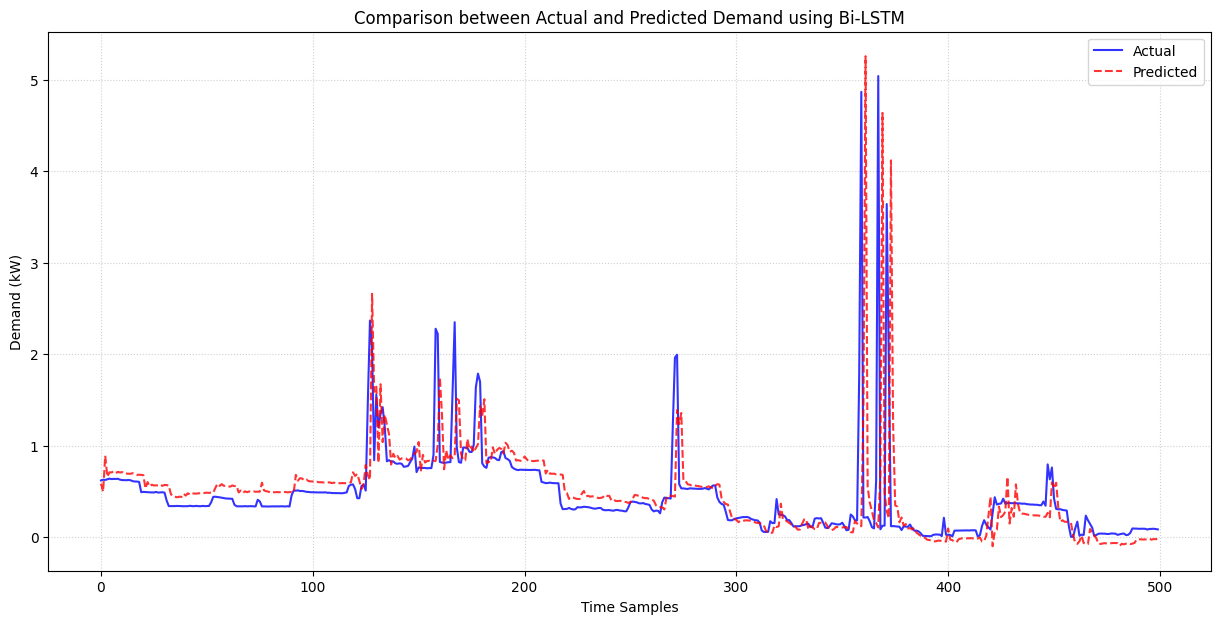

In [ ]:
plt.figure(figsize=(15, 7))
num_samples_to_plot = 500  # Plot a subset for better readability

plt.plot(y_test_actual[:num_samples_to_plot], label='Actual', color='blue', alpha=0.8)
plt.plot(preds_bilstm[:num_samples_to_plot], label='Predicted', color='red', linestyle='--', alpha=0.8)

plt.title('Comparison between Actual and Predicted Demand using Bi-LSTM')
plt.xlabel('Time Samples')
plt.ylabel('Demand (kW)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 📝 Step 10: Save Metrics for Model Comparison


In [ ]:
import os

RESULTS_PATH = '/content/drive/MyDrive/EnerVision_AI/Models/model_results.csv'

def save_model_result(model_name, mae, rmse, r2=None, path=RESULTS_PATH):
    """Append/update this model's metrics in the shared comparison file."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    row = pd.DataFrame([{'model': model_name, 'mae': mae, 'rmse': rmse, 'r2': r2}])

    if os.path.exists(path):
        existing = pd.read_csv(path)
        existing = existing[existing['model'] != model_name]
        df_out = pd.concat([existing, row], ignore_index=True)
    else:
        df_out = row

    df_out.to_csv(path, index=False)
    print(f"✅ Saved metrics for '{model_name}' to:\n{path}")
    print(df_out)

save_model_result('Bi-LSTM', mae_bilstm, rmse_bilstm, r2_bilstm)


✅ Saved metrics for 'Bi-LSTM' to:
/content/drive/MyDrive/EnerVision_AI/Models/model_results.csv
     model       mae      rmse        r2
0  XGBoost  0.134325  0.316297  0.768521
1  Bi-LSTM  0.213674  0.407828  0.615233


## 💾 Step 11: Save the Model


In [ ]:
import os
import joblib

save_dir = '/content/drive/MyDrive/EnerVision_AI/Models/BiLSTM'
os.makedirs(save_dir, exist_ok=True)

torch.save(model_bilstm.state_dict(), os.path.join(save_dir, 'bilstm_model.pt'))
joblib.dump(scaler_y, os.path.join(save_dir, 'scaler_y.joblib'))
joblib.dump(scaler_X, os.path.join(save_dir, 'scaler_X.joblib'))

print(f"✅ Bi-LSTM model and scalers successfully saved to:\n{save_dir}")


✅ Bi-LSTM model and scalers successfully saved to:
/content/drive/MyDrive/EnerVision_AI/Models/BiLSTM
